# Lab 04 - Taxi 10x10 ze ścianami

Celem notebooka jest wytrenowanie agenta **MaskablePPO** w środowisku taxi oraz pokazanie **krzywej uczenia**.

Wariant środowiska:
- siatka `10x10`,
- stałe ściany/przeszkody,
- losowe rozmieszczenie punktów `R/G/Y/B` przy każdym resecie,
- losowy pasażer i cel,
- obserwacja wektorowa,
- maskowanie niedozwolonych akcji,
- shaping nagrody oparty o najkrótszą ścieżkę BFS.

Środowisko jest importowane z pliku `custom_grid_taxi_env.py`, a logika treningu i rysowania krzywej uczenia znajduje się bezpośrednio w tym notebooku.

## 1. Importy i konfiguracja

Ta komórka ustawia bezpieczne zmienne dla macOS, importuje biblioteki oraz rejestruje środowisko z pliku `custom_grid_taxi_env.py`.

In [1]:
import os
import sys
from pathlib import Path

# macOS + PyTorch/OpenMP: ustaw przed importem torch/stable-baselines.
if sys.platform == "darwin":
    os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"
    os.environ["OPENBLAS_NUM_THREADS"] = "1"
    os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
    os.environ["NUMEXPR_NUM_THREADS"] = "1"
    os.environ["OBJC_DISABLE_INITIALIZE_FORK_SAFETY"] = "YES"

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from sb3_contrib import MaskablePPO
from sb3_contrib.common.maskable.callbacks import MaskableEvalCallback
from sb3_contrib.common.wrappers import ActionMasker
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

from custom_grid_taxi_env import (
    DEFAULT_GRID_SIZE,
    DEFAULT_MAX_EPISODE_STEPS,
    ENV_ID,
    register_custom_grid_taxi,
)

register_custom_grid_taxi()
plt.rcParams.update({"figure.dpi": 120, "font.family": "monospace"})

GRID_SIZE = 10
TOTAL_TIMESTEPS = 3_000_000
N_ENVS = 8
SEED = 42
FINAL_EVAL_EPISODES = 500

MODEL_VARIANT = "v1_10x10_walls_random_locs_vector"
MODEL_DIR = Path("models")
BEST_MODEL_DIR = MODEL_DIR / MODEL_VARIANT
BEST_MODEL_PATH = BEST_MODEL_DIR / "best_model.zip"
FINAL_MODEL_PATH = MODEL_DIR / "custom_grid_taxi_ppo_10x10_walls_random_locs_vector.zip"
LOG_DIR = MODEL_DIR / "logs_10x10_walls_random_locs_vector"
EVAL_FILE = LOG_DIR / "evaluations.npz"

print(f"Python: {sys.executable}")
print(f"Środowisko: {ENV_ID}")
print(f"Siatka: {GRID_SIZE}x{GRID_SIZE}, max_episode_steps={DEFAULT_MAX_EPISODE_STEPS}")
print(f"Trening: {TOTAL_TIMESTEPS:,} kroków, n_envs={N_ENVS}")

Python: /Users/antonio/IOwAnalizie/inteligencja_obliczeniowa_w_analizie_danych/lab04/taxi/.venv/bin/python
Środowisko: CustomGridTaxi-v0
Siatka: 10x10, max_episode_steps=250
Trening: 3,000,000 kroków, n_envs=8


## 2. Podgląd środowiska

Poniżej widać losowe rozmieszczenie punktów `R/G/Y/B`, pasażera, celu i taxi. Zmiana `seed` pokazuje inny układ.

In [2]:
env = gym.make(
    ENV_ID,
    render_mode="ansi",
    grid_size=GRID_SIZE,
    observation_mode="vector",
    max_episode_steps=DEFAULT_MAX_EPISODE_STEPS,
)
obs, info = env.reset(seed=7)

print(env.render())
print(f"Obserwacja: {env.observation_space}")
print(f"Akcje:      {env.action_space}")
print(f"Maska:      {info['action_mask']}  (1=akcja dozwolona)")
print(f"Punkty R/G/Y/B: {env.unwrapped.locs}")
env.close()

444444444444444444444
135353535353535353531
135353535353535353531
135353535353535353531
135353535353535353531
135353535353535353531
135353535353535353531
13535G535353535353531
1B5353535353535353531
135353535353535353531
135Y5R535353535353531
444444444444444444444


Obserwacja: Box(0.0, 1.0, (10,), float32)
Akcje:      Discrete(6)
Maska:      [1 1 1 1 0 0]  (1=akcja dozwolona)
Punkty R/G/Y/B: [(9, 2), (6, 2), (9, 1), (7, 0)]


## 3. Trening MaskablePPO

Trening działa przez `3_000_000` kroków. Callback `MaskableEvalCallback` zapisuje wyniki ewaluacji do `evaluations.npz`, które później wykorzystujemy do wykresu krzywej uczenia.

In [3]:
def linear_schedule(initial_value):
    def _schedule(progress_remaining):
        return float(progress_remaining) * initial_value
    return _schedule


def make_masked_env(render_mode=None):
    env = gym.make(
        ENV_ID,
        render_mode=render_mode,
        grid_size=GRID_SIZE,
        observation_mode="vector",
        max_episode_steps=DEFAULT_MAX_EPISODE_STEPS,
    )
    return ActionMasker(env, lambda e: e.unwrapped.action_masks())


def evaluate_model(model, n_episodes=500, seed=10_000):
    env = make_masked_env(render_mode=None)
    successes = 0
    rewards = []
    lengths = []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed + i)
        total_reward = 0.0
        for step in range(1, DEFAULT_MAX_EPISODE_STEPS + 1):
            action, _ = model.predict(obs, action_masks=env.action_masks(), deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(int(action))
            total_reward += reward
            if terminated or truncated:
                successes += int(terminated)
                rewards.append(total_reward)
                lengths.append(step)
                break
    env.close()
    return {
        "success_rate": successes / n_episodes,
        "mean_reward": float(np.mean(rewards)),
        "mean_length": float(np.mean(lengths)),
    }


base_env = gym.make(
    ENV_ID,
    grid_size=GRID_SIZE,
    observation_mode="vector",
    max_episode_steps=DEFAULT_MAX_EPISODE_STEPS,
)
check_env(base_env, warn=True)
base_env.close()

use_dummy_vec = sys.platform == "darwin" and N_ENVS > 1
vec_env_cls = DummyVecEnv if use_dummy_vec else None
if use_dummy_vec:
    print("macOS: używam DummyVecEnv zamiast subprocessów.")

train_env = make_vec_env(
    lambda: make_masked_env(render_mode=None),
    n_envs=N_ENVS,
    seed=SEED,
    vec_env_cls=vec_env_cls,
)
train_env = VecMonitor(train_env)
eval_env = Monitor(make_masked_env(render_mode=None))

MODEL_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

eval_freq = max(2_000, TOTAL_TIMESTEPS // (40 * N_ENVS))
eval_callback = MaskableEvalCallback(
    eval_env,
    best_model_save_path=str(BEST_MODEL_DIR),
    log_path=str(LOG_DIR),
    eval_freq=eval_freq,
    n_eval_episodes=50,
    deterministic=True,
    render=False,
)

ppo_kwargs = dict(
    learning_rate=linear_schedule(2.5e-4),
    n_steps=512,
    batch_size=256,
    n_epochs=8,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    target_kl=0.03,
    policy_kwargs=dict(net_arch=dict(pi=[128, 128], vf=[128, 128])),
)

print(f"Start treningu: {TOTAL_TIMESTEPS:,} kroków")
model = MaskablePPO("MlpPolicy", train_env, verbose=1, seed=SEED, **ppo_kwargs)
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback)
model.save(FINAL_MODEL_PATH)
print(f"Zapisano finalny model: {FINAL_MODEL_PATH}")

load_path = BEST_MODEL_PATH if BEST_MODEL_PATH.is_file() else FINAL_MODEL_PATH
best_model = MaskablePPO.load(load_path)
final_eval = evaluate_model(best_model, n_episodes=FINAL_EVAL_EPISODES)

print(f"Najlepszy checkpoint: {load_path}")
print(f"Skuteczność final eval ({FINAL_EVAL_EPISODES} ep.): {100 * final_eval['success_rate']:.1f}%")
print(f"Średnia nagroda: {final_eval['mean_reward']:.1f}")
print(f"Średnia długość epizodu: {final_eval['mean_length']:.1f}")

train_env.close()
eval_env.close()

macOS: używam DummyVecEnv zamiast subprocessów.
Start treningu: 3,000,000 kroków
Using cpu device


/Users/antonio/IOwAnalizie/inteligencja_obliczeniowa_w_analizie_danych/lab04/taxi/.venv/lib/python3.12/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 238      |
|    ep_rew_mean     | -34.2    |
| time/              |          |
|    fps             | 29798    |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 4096     |
---------------------------------


/Users/antonio/IOwAnalizie/inteligencja_obliczeniowa_w_analizie_danych/lab04/taxi/.venv/lib/python3.12/site-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_monitor.VecMonitor object at 0x14822a930> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x113450050>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 242          |
|    ep_rew_mean          | -26.7        |
| time/                   |              |
|    fps                  | 18310        |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.0089109745 |
|    clip_fraction        | 0.0815       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.11        |
|    explained_variance   | 0.000881     |
|    learning_rate        | 0.00025      |
|    loss                 | 28.7         |
|    n_updates            | 8            |
|    policy_gradient_loss | -0.00939     |
|    value_loss           | 42           |
------------------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len

## 4. Krzywa uczenia

Wykres jest tworzony z pliku `models/logs_10x10_walls_random_locs_vector/evaluations.npz`, zapisanego podczas treningu. Pokazuje średnią nagrodę, długość epizodu oraz skuteczność dostaw w kolejnych punktach ewaluacji.

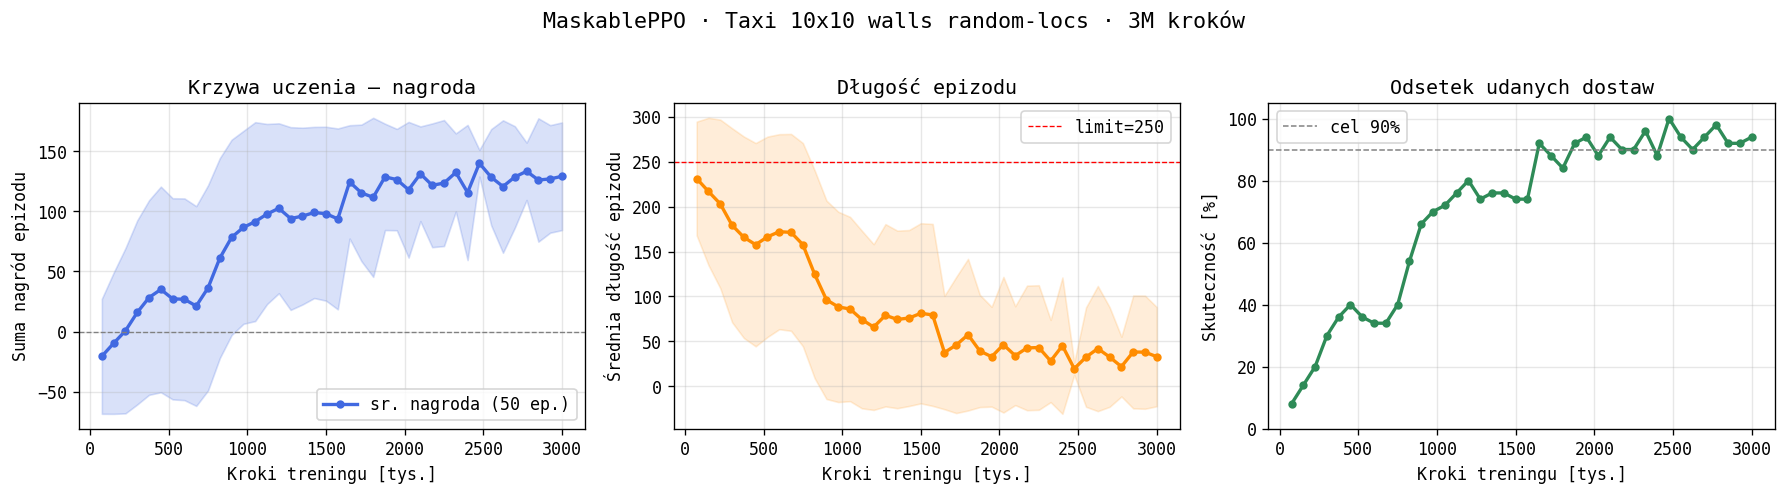

Najlepsza sr. nagroda: 140.1 przy 2475k kroków
Końcowa skuteczność:   94.0%
Końcowa dł. epizodu:   33.0 kroków


In [4]:
if not EVAL_FILE.is_file():
    raise FileNotFoundError(f"Brak {EVAL_FILE}. Najpierw uruchom komórkę treningu.")

data = np.load(EVAL_FILE)
timesteps = data["timesteps"] / 1_000
rewards = data["results"]
lengths = data["ep_lengths"]

mean_reward = rewards.mean(axis=1)
std_reward = rewards.std(axis=1)
mean_length = lengths.mean(axis=1)
std_length = lengths.std(axis=1)
success_rate = (lengths < DEFAULT_MAX_EPISODE_STEPS).mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.fill_between(timesteps, mean_reward - std_reward, mean_reward + std_reward, alpha=0.2, color="royalblue")
ax.plot(timesteps, mean_reward, "o-", color="royalblue", lw=2, ms=4, label="sr. nagroda (50 ep.)")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Kroki treningu [tys.]")
ax.set_ylabel("Suma nagród epizodu")
ax.set_title("Krzywa uczenia - nagroda")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.fill_between(timesteps, mean_length - std_length, mean_length + std_length, alpha=0.15, color="darkorange")
ax.plot(timesteps, mean_length, "o-", color="darkorange", lw=2, ms=4)
ax.axhline(DEFAULT_MAX_EPISODE_STEPS, color="red", lw=0.8, ls="--", label=f"limit={DEFAULT_MAX_EPISODE_STEPS}")
ax.set_xlabel("Kroki treningu [tys.]")
ax.set_ylabel("Średnia długość epizodu")
ax.set_title("Długość epizodu")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(timesteps, 100 * success_rate, "o-", color="seagreen", lw=2, ms=4)
ax.axhline(90, color="gray", lw=0.9, ls="--", label="cel 90%")
ax.set_xlabel("Kroki treningu [tys.]")
ax.set_ylabel("Skuteczność [%]")
ax.set_title("Odsetek udanych dostaw")
ax.set_ylim(0, 105)
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle("MaskablePPO · Taxi 10x10 walls random-locs · 3M kroków", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

best_idx = mean_reward.argmax()
print(f"Najlepsza sr. nagroda: {mean_reward[best_idx]:.1f} przy {timesteps[best_idx]:.0f}k kroków")
print(f"Końcowa skuteczność:   {100 * success_rate[-1]:.1f}%")
print(f"Końcowa dł. epizodu:   {mean_length[-1]:.1f} kroków")

## 5. Przykładowa ewaluacja agenta

Po treningu można uruchomić jeden epizod z najlepszym zapisanym modelem. Zmieniaj `SEED`, aby uzyskać inne rozmieszczenie punktów i taxi.

In [5]:
RUN_MODE = "ansi"   # "ansi" albo "human"
SEED = 7
FPS = 6
ACTIONS = {0: "S", 1: "N", 2: "E", 3: "W", 4: "PICK", 5: "DROP"}

if not BEST_MODEL_PATH.is_file():
    raise FileNotFoundError(f"Brak modelu {BEST_MODEL_PATH}. Najpierw uruchom trening.")

model = MaskablePPO.load(BEST_MODEL_PATH)
env = make_masked_env(render_mode=RUN_MODE)
obs, _ = env.reset(seed=SEED)
total_reward = 0.0

print(f"Model: {BEST_MODEL_PATH}")
print(f"Seed: {SEED}")
print(f"Punkty R/G/Y/B: {env.unwrapped.locs}")
if RUN_MODE == "ansi":
    print(env.render())

for step in range(1, DEFAULT_MAX_EPISODE_STEPS + 1):
    action, _ = model.predict(obs, action_masks=env.action_masks(), deterministic=True)
    obs, reward, terminated, truncated, _ = env.step(int(action))
    total_reward += reward

    if RUN_MODE == "ansi":
        if reward > 5 or step <= 5 or terminated or truncated:
            print(f"krok {step:3d}: {ACTIONS[int(action)]:4s}  r={reward:+.1f}  suma={total_reward:.1f}")
        if terminated or truncated:
            print(env.render())
    else:
        env.render()
        time.sleep(max(0.01, 1.0 / FPS))

    if terminated or truncated:
        status = "SUKCES" if terminated else "TIMEOUT"
        print(f"{status}: krok={step}, suma nagród={total_reward:.1f}")
        break

env.close()

Model: models/v1_10x10_walls_random_locs_vector/best_model.zip
Seed: 7
Punkty R/G/Y/B: [(9, 2), (6, 2), (9, 1), (7, 0)]
444444444444444444444
135353535353535353531
135353535353535353531
135353535353535353531
135353535353535353531
135353535353535353531
135353535353535353531
13535G535353535353531
1B5353535353535353531
135353535353535353531
135Y5R535353535353531
444444444444444444444


krok   1: W     r=+1.8  suma=1.8
krok   2: S     r=+1.8  suma=3.6
krok   3: W     r=+1.8  suma=5.4
krok   4: W     r=+1.8  suma=7.2
krok   5: S     r=+1.8  suma=9.0
krok  14: PICK  r=+10.0  suma=33.4
krok  18: DROP  r=+100.0  suma=138.8
444444444444444444444
135353535353535353531
135353535353535353531
135353535353535353531
135353535353535353531
135353535353535353531
135353535353535353531
13535G535353535353531
1B5353535353535353531
135353535353535353531
135Y5R535353535353531
444444444444444444444
  (Dropoff)

SUKCES: krok=18, suma nagród=138.8


# Raport: własne środowisko Taxi i trening MaskablePPO

**Autorzy:** Antoni Pater, Mateusz Sobiech

## Cel ćwiczenia

Celem projektu było przygotowanie własnego środowiska typu Taxi w bibliotece Gymnasium oraz wytrenowanie agenta uczącego się dowożenia pasażera do celu. Agent korzysta z algorytmu MaskablePPO, czyli wariantu PPO obsługującego maskowanie niedozwolonych akcji.

Końcowy wariant środowiska działa na siatce `10x10`, zawiera przeszkody, losowe rozmieszczenie punktów `R/G/Y/B` oraz losowo wybieranego pasażera i cel. Dzięki temu agent nie uczy się jednej stałej trasy, tylko musi reagować na aktualny układ zadania.

Raport opisuje finalną wersję środowiska, sposób uczenia agenta, interpretację krzywej uczenia oraz przykładowe zrzuty ekranu pokazujące różne rozmieszczenia pól na planszy.

## Środowisko

Środowisko znajduje się w pliku `lab04/taxi/custom_grid_taxi_env.py`, a finalny notebook do uruchamiania treningu i rysowania krzywej uczenia to `lab04/taxi/lab04_taxi_final.ipynb`.

Najważniejsze cechy środowiska:

- plansza ma rozmiar `10x10`,
- część pól jest zablokowana jako ściany/przeszkody,
- taxi nie może wjechać w przeszkodę,
- punkty `R/G/Y/B` są losowane na wolnych polach przy każdym resecie,
- pasażer startuje w jednym z punktów `R/G/Y/B`,
- cel jest losowany jako inny punkt niż punkt startowy pasażera,
- taxi startuje z losowego wolnego pola,
- epizod kończy się sukcesem po poprawnym dowiezieniu pasażera do celu.

## Losowe rozmieszczenie punktów

W klasycznym Taxi punkty odbioru i dostawy są zwykle stałe, np. w rogach mapy. W tym projekcie zostało to zmienione. Przy każdym wywołaniu `reset()` środowisko losuje cztery różne wolne pola i przypisuje im etykiety `R`, `G`, `Y`, `B`.

Takie podejście sprawia, że:

- agent nie może zapamiętać jednej konkretnej trasy,
- pasażer i cel mogą znajdować się w różnych miejscach w kolejnych epizodach,
- środowisko jest trudniejsze i bardziej uogólnione,
- obserwacja musi zawierać informację o aktualnym źródle, celu i pozycji taxi.

Przeszkody pozostają stałe, ale punkty `R/G/Y/B`, pasażer, cel oraz pozycja taxi są losowe. Dzięki temu na tej samej mapie powstaje wiele różnych wariantów zadania.

## Obserwacja i akcje

Agent otrzymuje obserwację wektorową typu `Box(10,)`. Wektor zawiera znormalizowane informacje o:

- pozycji taxi,
- stanie pasażera,
- pozycji źródła pasażera,
- pozycji celu,
- aktualnym celu nawigacyjnym,
- odległości do aktualnego celu liczonej najkrótszą ścieżką BFS.

Dostępne akcje:

| Numer | Akcja |
|---:|---|
| 0 | ruch w dół |
| 1 | ruch w górę |
| 2 | ruch w prawo |
| 3 | ruch w lewo |
| 4 | pickup |
| 5 | dropoff |

Środowisko zwraca maskę akcji. Maska blokuje m.in. ruch w ścianę, pickup w złym miejscu oraz dropoff poza właściwym celem.

## Nagrody

Nagrody zostały dobrane tak, aby agent otrzymywał czytelny sygnał uczenia:

| Zdarzenie | Nagroda |
|---|---:|
| każdy krok | `-0.2` |
| poprawny pickup | `+10` |
| poprawny dropoff | `+100` |
| błędny pickup/dropoff | `-10` |
| zbliżenie do aktualnego celu | `+2.0 * (d_stare - d_nowe)` |

Odległość `d` jest liczona algorytmem BFS, a nie prostym Manhattanem. Jest to ważne, ponieważ na planszy występują ściany. Dystans Manhattan mógłby sugerować ruch w stronę przeszkody, natomiast BFS uwzględnia faktycznie dostępne przejścia.

## Algorytm

Do treningu użyto `MaskablePPO` z pakietu `sb3_contrib`. Jest to PPO rozszerzone o obsługę masek akcji. Dzięki temu agent nie losuje akcji niemożliwych do wykonania, np. wjazdu w ścianę.

Najważniejsze hiperparametry:

| Parametr | Wartość |
|---|---:|
| liczba kroków treningu | `3_000_000` |
| liczba środowisk równoległych | `8` |
| `learning_rate` | liniowy harmonogram od `2.5e-4` |
| `n_steps` | `512` |
| `batch_size` | `256` |
| `n_epochs` | `8` |
| `gamma` | `0.99` |
| `gae_lambda` | `0.95` |
| `clip_range` | `0.2` |
| `ent_coef` | `0.01` |
| `vf_coef` | `0.5` |
| `target_kl` | `0.03` |
| architektura sieci | `pi=[128, 128]`, `vf=[128, 128]` |

Model zapisuje się do:

```text
lab04/taxi/models/v1_10x10_walls_random_locs_vector/best_model.zip
```

## Krzywa uczenia

Krzywa uczenia jest najważniejszym wynikiem eksperymentu, ponieważ pokazuje, czy agent faktycznie nauczył się realizować zadanie, a nie tylko wykonywać pojedyncze poprawne akcje. Wykres został wygenerowany w notebooku `lab04/taxi/lab04_taxi_final.ipynb` na podstawie okresowych ewaluacji modelu.

![Krzywa uczenia agenta](krzywa-uczenia.png)

Dane do wykresu są zapisywane w pliku:

```text
lab04/taxi/models/logs_10x10_walls_random_locs_vector/evaluations.npz
```

Wykres składa się z trzech części, które razem pokazują jakość wyuczonej polityki:

- średnia nagroda epizodu,
- średnia długość epizodu,
- skuteczność dostaw w procentach.

Na początku treningu skuteczność jest niska, ponieważ agent dopiero poznaje znaczenie akcji, punktów `R/G/Y/B` i masek akcji. W kolejnych etapach rośnie średnia nagroda, maleje średnia długość epizodu, a odsetek udanych dostaw przekracza cel `90%`. Oznacza to, że agent nauczył się nie tylko dowozić pasażera, ale robić to coraz krótszą trasą.

Najważniejszy jest trzeci wykres, ponieważ pokazuje, jaki odsetek epizodów zakończył się poprawnym dowiezieniem pasażera do celu. Dodatkowo długość epizodu pokazuje, czy agent uczy się dostarczać pasażera szybciej, a średnia nagroda pokazuje ogólny postęp polityki.

## Uruchomienie

Trening i krzywa uczenia są uruchamiane z notebooka:

```text
lab04/taxi/lab04_taxi_final.ipynb
```

Notebook należy uruchomić od góry. Najważniejsze sekcje:

- `3. Trening MaskablePPO` uruchamia trening,
- `4. Krzywa uczenia` rysuje wykres,
- `5. Przykładowa ewaluacja agenta` uruchamia jeden epizod gry.

W ostatniej sekcji można zmienić tryb:

```python
RUN_MODE = "ansi"
```

na:

```python
RUN_MODE = "human"
```

Wtedy uruchamia się okno `pygame` z graficznym podglądem gry.

## Zrzuty ekranu gry

Poniższe obrazy pokazują graficzny podgląd środowiska. Każdy reset może wygenerować inne rozmieszczenie punktów `R/G/Y/B`, inną pozycję taxi oraz inny wybór pasażera i celu. Dzięki temu plansza nie sprowadza się do jednej zapamiętanej trasy.

### Przykład 1: losowe rozmieszczenie punktów

![Pierwszy układ gry](first-img.png)

Opis: punkty `R/G/Y/B` znajdują się w losowych miejscach na wolnych polach mapy. Taxi startuje z losowego pola, a pasażer i cel są wybrane z aktualnych punktów.

### Przykład 2: inny układ po zmianie seed/reset

![Drugi układ gry](drugi-obraz.png)

Opis: po zmianie seeda lub kolejnym resecie punkty `R/G/Y/B` są rozmieszczone inaczej. To pokazuje, że środowisko nie jest jedną zapamiętaną trasą.

### Znaczenie losowych układów

Losowe rozmieszczenie punktów jest ważne dla oceny jakości agenta. Gdyby punkty były zawsze w tych samych miejscach, agent mógłby nauczyć się prostego schematu poruszania po mapie. W finalnej wersji musi odczytać aktualną obserwację, odnaleźć pasażera, wykonać `pickup`, a następnie dowieźć go do aktualnie wskazanego celu.

## Wnioski

Zastosowanie masek akcji znacząco upraszcza problem, ponieważ agent nie musi eksplorować ruchów niemożliwych, takich jak wejście w ścianę. Dodatkowo shaping oparty o BFS daje poprawny sygnał kierunku nawet na mapie z przeszkodami.

Losowe rozmieszczenie punktów `R/G/Y/B` zwiększa trudność zadania, ale poprawia ogólność rozwiązania. Agent nie uczy się jednej trasy, tylko musi wykorzystywać obserwację zawierającą aktualne pozycje źródła, celu i taxi.

Końcowy notebook zawiera pełny proces: definicję konfiguracji, trening MaskablePPO, zapis modelu, krzywą uczenia oraz uruchomienie przykładowego epizodu gry.
